<a href="https://colab.research.google.com/github/Namitha-04/Credit-Card-Fraud-detection/blob/main/Creditcardfrauddet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
from sklearn.preprocessing import StandardScaler

In [58]:
df = pd.read_csv("creditcard.csv")

In [59]:
print(df.shape) #prints the number of rows and columns
print(df.head()) #prints the first five rows of the dataset

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [60]:
print(df.info) #all the entries
print(df.dtypes) #the datatypes of each column

<bound method DataFrame.info of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  

In [61]:
print(df['Class'].value_counts()) #counts the number of frauds and the nummber of legit

Class
0    284315
1       492
Name: count, dtype: int64


In [62]:
scaler = StandardScaler()

In [63]:
X = df.drop('Class', axis=1) #We are storing the data in 2 different variables, x is the data the model will learn from
y = df['Class'] #y is the data the model will predict
print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


In [64]:
print (y.isnull().sum()) #This checks all the null values and gives us the count
print (df.isnull().sum()) #This checks all the columns

0
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [65]:
df['scaled_Amount'] = scaler.fit_transform(df[['Amount']]) #scaling is done to reduce the difference in the range of number, basically from being at a difference of mmillions,
df['scaled_time'] = scaler.fit_transform(df[['Time']])# it could be at a difference of a few decimal points

In [66]:
df = df.drop(['Amount', 'Time'], axis=1)#Snce we didn't need the original values, we drop the 2 columns
print(df.head())

         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28  Class  scaled_Amount  scaled_time  

In [67]:
df=df.dropna() #This drops any of the rows that have a null value
print(df.shape)

(284807, 31)


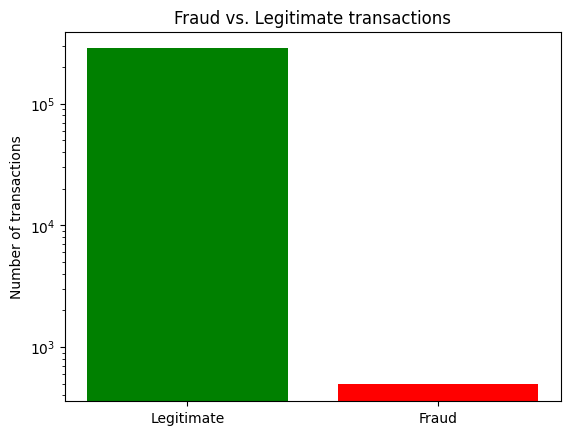

In [68]:
count = df['Class'].value_counts()
plt.bar(['Legitimate', 'Fraud'], count.values, color=['green', 'red'])
plt.title('Fraud vs. Legitimate transactions')
plt.ylabel('Number of transactions')
plt.yscale('log') #to show the fraud graph since the number was less compared to the legit ones
plt.show()

Since the scale of y had to be turned into log scale, there might not be accurate readings so, the alternate is

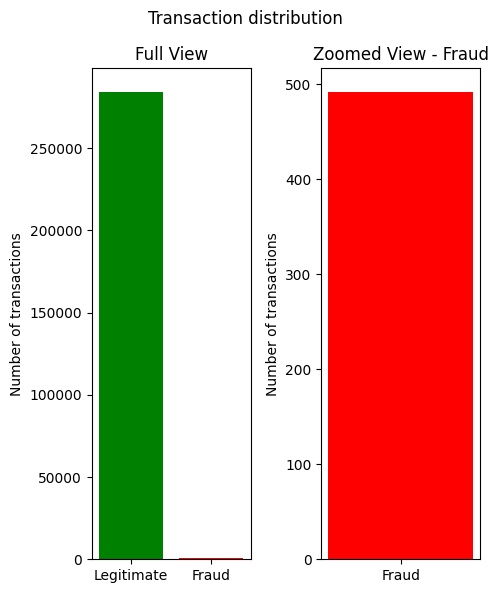

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(5,6))

axes[0].bar(['Legitimate', 'Fraud'], count.values, color=['green', 'red'])
axes[0].set_title('Full View')
axes[0].set_ylabel('Number of transactions')

axes[1].bar(['Fraud'], [count[1]], color=['red'])
axes[1].set_title('Zoomed View - Fraud')
axes[1].set_ylabel('Number of transactions')

plt.suptitle('Transaction distribution')
plt.tight_layout()
plt.show()
#this method shows the near approx. values through visuals

In [70]:
print(f"Legitimate: {count[0]}") #using the f-string, they perform calculations
print("fraud:" , count[1])# usual printing
print(f"fraud %: {count[1] / len(df)*100: .2f}%")

Legitimate: 284315
fraud: 492
fraud %:  0.17%


In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])
print("Fraud in train:", y_train.sum())
print("Fraud in test :", y_test.sum())

Train size: 227845
Test size : 56962
Fraud in train: 394
Fraud in test : 98


In [72]:
from imblearn.over_sampling import SMOTE

In [73]:
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("Before SMOTE: ")
print("Legit: ", sum(y_train ==0 ))
print("fraud: ", sum(y_train ==1 ))
print("After SMOTE: ")
print("Legit: ", sum(y_train_sm ==0 ))
print("fraud: ", sum(y_train_sm ==1))

Before SMOTE: 
Legit:  227451
fraud:  394
After SMOTE: 
Legit:  227451
fraud:  227451


In [74]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sm, y_train_sm)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [75]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators = 100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sm, y_train_sm)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [76]:
import xgboost as xgb
scale = sum(y_train==0)/ sum(y_train == 1)
xgb_model = xgb.XGBClassifier(
    n_estimators = 100,
    scale_pos_weight = scale,
    eval_metric = 'logloss',
    verbosity = 0
)
xgb_model.fit(X_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [77]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
models = { "Logistic regression": lr_model, "Random Forest": rf_model, "XGBoost": xgb_model }
for name, model in models.items():
  y_pred = model.predict(X_test)
  y_proba = model.predict_proba(X_test)[:1]
  print (f"\n{'='*50}")
  print(classification_report(y_test, y_pred,
          target_names=['Legitimate', 'Fraud']))



              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56864
       Fraud       0.11      0.92      0.20        98

    accuracy                           0.99     56962
   macro avg       0.56      0.95      0.60     56962
weighted avg       1.00      0.99      0.99     56962


              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.91      0.81      0.85        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962


              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.76      0.89      0.82        98

    accuracy                           1.00     56962
   macro avg       0.88      0.94      0.91     56962
weighted avg       1.00      1.00      1.00     56962



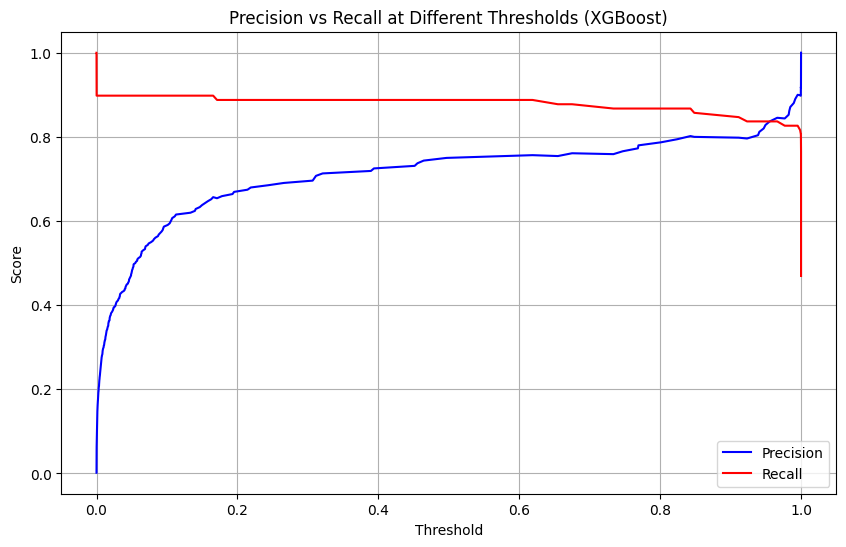

In [79]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)

# Plot the curve
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='red')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds (XGBoost)')
plt.legend()
plt.grid(True)
plt.show()

In [80]:
f1_scores = 2*(precisions[:-1]*recalls[:-1])/ (precisions[:-1] + recalls[:-1])
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
print(f"Best threshold: {best_threshold}")
print(f"Best F1 score: {best_f1}")

Best threshold: 0.9999804496765137
Best F1 score: 0.8620689655172413


In [81]:
y_pred_tuned = (y_proba_xgb >= best_threshold).astype(int)

print("\nResults WITH tuned threshold:")
print(classification_report(y_test, y_pred_tuned,
      target_names=['Legitimate', 'Fraud']))


Results WITH tuned threshold:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.99      0.77      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962

